# ⭐ Day 11: NumPy Mathematical Operations & Broadcasting  
Master Efficient Computations for AI & ML | Step-by-Step Tutorial with Examples & Exercises  

*Day 11 of 369-day Python & AI Learning Path*

## Introduction

Welcome to Day 11 of your Python & AI Learning Path! Today we're diving deep into NumPy's mathematical operations and broadcasting capabilities—two of the most powerful features that make NumPy indispensable for AI and machine learning.

Mathematical operations and broadcasting are the backbone of modern AI/ML workflows. They power neural network forward passes where thousands of operations happen simultaneously, enable efficient loss calculations across entire batches of data, and make gradient computations feasible for deep learning. When you normalize features, compute distance metrics, or perform matrix multiplications in your ML models, you're leveraging these exact NumPy capabilities.

Broadcasting is particularly magical—it allows NumPy to perform operations on arrays of different shapes without creating explicit copies of data. This means you can add a scalar to an entire matrix, combine vectors with matrices, or perform complex operations between arrays of different dimensions, all while keeping your code clean, readable, and incredibly fast. In AI/ML, this translates to efficient batch processing, vectorized feature transformations, and memory-efficient computations.

By mastering these concepts today, you'll write code that is not only 10-100x faster than pure Python loops but also more readable and maintainable. Whether you're implementing a custom loss function, preprocessing data, or building neural networks from scratch, the skills you learn today will be your foundation for writing professional-grade ML code. Let's transform how you think about array computations!

## 📌 Table of Contents

1. [Arithmetic Operations on Arrays](#arithmetic-operations)
2. [Universal Functions (ufuncs) Deep Dive](#universal-functions)
3. [Broadcasting Rules Explained](#broadcasting-rules)
4. [Broadcasting in Practice](#broadcasting-practice)
5. [Advanced Operations: Dot Products & Matrix Multiplication](#advanced-operations)
6. [Statistical and Aggregation Operations](#statistical-operations)
7. [Trigonometric, Exponential, and Logarithmic Functions](#math-functions)
8. [Comparison and Logical Operations](#logical-operations)
9. [Practical AI/ML Examples](#ml-examples)
10. [🛠️ Hands-On Exercises](#exercises)
11. [Solutions](#solutions)

## Arithmetic Operations on Arrays {#arithmetic-operations}

NumPy allows you to perform element-wise arithmetic operations on arrays using standard operators. These operations are vectorized, meaning they are applied to entire arrays at once without explicit loops.

In [1]:
import numpy as np

# Create sample arrays
a = np.array([1, 2, 3, 4, 5])
b = np.array([10, 20, 30, 40, 50])

print(f"Array a: {a}")
print(f"Array b: {b}")
print()

# Basic arithmetic operations
print("Addition (a + b):       ", a + b)
print("Subtraction (a - b):    ", a - b)
print("Multiplication (a * b): ", a * b)
print("Division (b / a):       ", b / a)
print("Power (a ** 2):         ", a ** 2)
print("Modulo (b % 3):         ", b % 3)

# Using NumPy functions (equivalent to operators)
print("\nUsing np.add():         ", np.add(a, b))
print("Using np.multiply():    ", np.multiply(a, b))

Array a: [1 2 3 4 5]
Array b: [10 20 30 40 50]

Addition (a + b):        [11 22 33 44 55]
Subtraction (a - b):     [ -9 -18 -27 -36 -45]
Multiplication (a * b):  [ 10  40  90 160 250]
Division (b / a):        [10. 10. 10. 10. 10.]
Power (a ** 2):          [ 1  4  9 16 25]
Modulo (b % 3):          [1 2 0 1 2]

Using np.add():          [11 22 33 44 55]
Using np.multiply():     [ 10  40  90 160 250]


## Universal Functions (ufuncs) Deep Dive {#universal-functions}

Universal functions (ufuncs) are NumPy's way of vectorizing operations. They perform element-wise operations on arrays and are highly optimized for performance. Ufuncs are essential in ML for activation functions, loss calculations, and feature transformations.

In [2]:
import numpy as np

# Create sample data
x = np.array([1, 2, 3, 4, 5], dtype=float)

# Mathematical ufuncs commonly used in ML
print("Original array:", x)
print()

# Exponential and logarithmic (used in softmax, cross-entropy)
print("np.exp(x):   ", np.exp(x))     # e^x - used in softmax
print("np.log(x):   ", np.log(x))     # natural log - used in loss functions
print("np.log2(x):  ", np.log2(x))    # log base 2
print("np.log10(x): ", np.log10(x))   # log base 10
print("np.sqrt(x):  ", np.sqrt(x))    # square root

# Trigonometric functions (used in positional encodings, signal processing)
angles = np.array([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
print("\nAngles:", angles)
print("np.sin(angles):", np.sin(angles))
print("np.cos(angles):", np.cos(angles))

# Rounding functions
y = np.array([1.2, 2.5, 3.7, 4.1])
print("\nOriginal:  ", y)
print("np.round():", np.round(y))
print("np.floor():", np.floor(y))
print("np.ceil(): ", np.ceil(y))

Original array: [1. 2. 3. 4. 5.]

np.exp(x):    [  2.71828183   7.3890561   20.08553692  54.59815003 148.4131591 ]
np.log(x):    [0.         0.69314718 1.09861229 1.38629436 1.60943791]
np.log2(x):   [0.         1.         1.5849625  2.         2.32192809]
np.log10(x):  [0.         0.30103    0.47712125 0.60205999 0.69897   ]
np.sqrt(x):   [1.         1.41421356 1.73205081 2.         2.23606798]

Angles: [0.         0.78539816 1.57079633 2.35619449 3.14159265]
np.sin(angles): [0.00000000e+00 7.07106781e-01 1.00000000e+00 7.07106781e-01
 1.22464680e-16]
np.cos(angles): [ 1.00000000e+00  7.07106781e-01  6.12323400e-17 -7.07106781e-01
 -1.00000000e+00]

Original:   [1.2 2.5 3.7 4.1]
np.round(): [1. 2. 4. 4.]
np.floor(): [1. 2. 3. 4.]
np.ceil():  [2. 3. 4. 5.]


## Broadcasting Rules Explained {#broadcasting-rules}

💡 **Broadcasting** is NumPy's ability to perform arithmetic operations on arrays of different shapes. It follows specific rules:

1. **Rule 1**: If arrays have different dimensions, prepend 1s to the shape of the smaller array.
2. **Rule 2**: Arrays are compatible in a dimension if they have the same size or one of them is 1.
3. **Rule 3**: Arrays can be broadcast together if they are compatible in all dimensions.

Let's visualize how broadcasting works with clear examples.

x shape: (5,), values: [0 1 2 3 4]
y shape: (4,), values: [0 1 2 3]

X shape: (4, 5)
Y shape: (4, 5)
Z = X + Y shape: (4, 5)

Z values:
[[0 1 2 3 4]
 [1 2 3 4 5]
 [2 3 4 5 6]
 [3 4 5 6 7]]


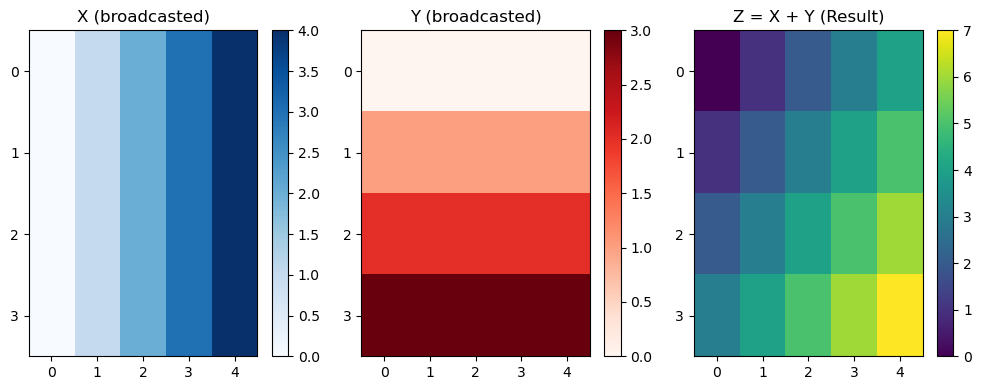

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Visual demonstration of broadcasting with meshgrid
x = np.arange(0, 5)  # Shape: (5,)
y = np.arange(0, 4)  # Shape: (4,)

print(f"x shape: {x.shape}, values: {x}")
print(f"y shape: {y.shape}, values: {y}")

# Broadcasting with meshgrid
X, Y = np.meshgrid(x, y)
Z = X + Y  # Broadcasting addition

print(f"\nX shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"Z = X + Y shape: {Z.shape}")
print("\nZ values:")
print(Z)

# Visualize broadcasting
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(X, cmap='Blues', aspect='auto')
plt.title('X (broadcasted)')
plt.colorbar()
plt.xticks(range(5))
plt.yticks(range(4))

plt.subplot(1, 3, 2)
plt.imshow(Y, cmap='Reds', aspect='auto')
plt.title('Y (broadcasted)')
plt.colorbar()
plt.xticks(range(5))
plt.yticks(range(4))

plt.subplot(1, 3, 3)
plt.imshow(Z, cmap='viridis', aspect='auto')
plt.title('Z = X + Y (Result)')
plt.colorbar()
plt.xticks(range(5))
plt.yticks(range(4))

plt.tight_layout()
plt.show()

## Broadcasting in Practice {#broadcasting-practice}

Let's explore practical broadcasting scenarios you'll encounter in ML: adding scalars, combining vectors with matrices, and operations between different shaped arrays.

In [4]:
import numpy as np

# Scenario 1: Scalar broadcasting (feature scaling)
features = np.array([[1, 2, 3],
                     [4, 5, 6],
                     [7, 8, 9]])
scale_factor = 2.5

print("Original features shape:", features.shape)
print("Scalar:", scale_factor)
scaled = features * scale_factor
print("Scaled features shape:", scaled.shape)
print("Scaled features:\n", scaled)

# Scenario 2: Row vector broadcasting (adding bias)
print("\n" + "="*50)
weights = np.array([[0.1, 0.2, 0.3],
                    [0.4, 0.5, 0.6]])  # Shape: (2, 3)
bias = np.array([1, 2, 3])              # Shape: (3,) -> broadcasts to (2, 3)

print(f"Weights shape: {weights.shape}")
print(f"Bias shape: {bias.shape} -> broadcasts to {weights.shape}")
result = weights + bias
print(f"Result shape: {result.shape}")
print("Result:\n", result)

# Scenario 3: Column vector broadcasting
print("\n" + "="*50)
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9],
                   [10, 11, 12]])  # Shape: (4, 3)
col_vector = np.array([[1], [2], [3], [4]])  # Shape: (4, 1)

print(f"Matrix shape: {matrix.shape}")
print(f"Column vector shape: {col_vector.shape}")
result = matrix + col_vector
print(f"Result shape: {result.shape}")
print("Result:\n", result)

Original features shape: (3, 3)
Scalar: 2.5
Scaled features shape: (3, 3)
Scaled features:
 [[ 2.5  5.   7.5]
 [10.  12.5 15. ]
 [17.5 20.  22.5]]

Weights shape: (2, 3)
Bias shape: (3,) -> broadcasts to (2, 3)
Result shape: (2, 3)
Result:
 [[1.1 2.2 3.3]
 [1.4 2.5 3.6]]

Matrix shape: (4, 3)
Column vector shape: (4, 1)
Result shape: (4, 3)
Result:
 [[ 2  3  4]
 [ 6  7  8]
 [10 11 12]
 [14 15 16]]


## Advanced Operations: Dot Products & Matrix Multiplication {#advanced-operations}

Matrix operations are fundamental in AI/ML for neural network layers, transformations, and distance calculations. NumPy provides several ways to perform these operations.

In [5]:
import numpy as np

# Matrix multiplication examples
A = np.array([[1, 2],
              [3, 4],
              [5, 6]])      # Shape: (3, 2)
B = np.array([[7, 8, 9],
              [10, 11, 12]]) # Shape: (2, 3)

print(f"A shape: {A.shape}")
print(f"B shape: {B.shape}")

# Method 1: np.dot()
C_dot = np.dot(A, B)
print(f"\nnp.dot(A, B) shape: {C_dot.shape}")
print(C_dot)

# Method 2: np.matmul() (preferred for matrix multiplication)
C_matmul = np.matmul(A, B)
print(f"\nnp.matmul(A, B) shape: {C_matmul.shape}")
print(C_matmul)

# Method 3: @ operator (Python 3.5+, most readable)
C_at = A @ B
print(f"\nA @ B shape: {C_at.shape}")
print(C_at)

# Outer product (useful in kernel methods)
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5])
outer = np.outer(v1, v2)
print(f"\nOuter product of {v1} and {v2}:")
print(outer)
print(f"Shape: {outer.shape}")

# Inner product (dot product of 1D arrays)
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
inner = np.inner(a, b)
print(f"\nInner product of {a} and {b}: {inner}")  # 1*4 + 2*5 + 3*6 = 32

A shape: (3, 2)
B shape: (2, 3)

np.dot(A, B) shape: (3, 3)
[[ 27  30  33]
 [ 61  68  75]
 [ 95 106 117]]

np.matmul(A, B) shape: (3, 3)
[[ 27  30  33]
 [ 61  68  75]
 [ 95 106 117]]

A @ B shape: (3, 3)
[[ 27  30  33]
 [ 61  68  75]
 [ 95 106 117]]

Outer product of [1 2 3] and [4 5]:
[[ 4  5]
 [ 8 10]
 [12 15]]
Shape: (3, 2)

Inner product of [1 2 3] and [4 5 6]: 32


## Statistical and Aggregation Operations {#statistical-operations}

Understanding axis-wise operations is crucial for batch processing in ML. The `axis` parameter determines which dimension to aggregate over.

In [6]:
import numpy as np

# Create sample batch data (batch_size=3, features=4)
data = np.array([[1, 2, 3, 4],
                 [5, 6, 7, 8],
                 [9, 10, 11, 12]])

print("Data shape:", data.shape)  # (3, 4)
print("Data:\n", data)

# axis=0: operations along rows (column-wise)
print("\n--- Axis 0 (column-wise, collapses rows) ---")
print(f"np.sum(data, axis=0):   {np.sum(data, axis=0)}")    # Sum of each column
print(f"np.mean(data, axis=0):  {np.mean(data, axis=0)}")   # Mean of each column
print(f"np.std(data, axis=0):   {np.std(data, axis=0)}")    # Std of each column
print(f"np.min(data, axis=0):   {np.min(data, axis=0)}")    # Min of each column
print(f"np.max(data, axis=0):   {np.max(data, axis=0)}")    # Max of each column

# axis=1: operations along columns (row-wise)
print("\n--- Axis 1 (row-wise, collapses columns) ---")
print(f"np.sum(data, axis=1):   {np.sum(data, axis=1)}")    # Sum of each row
print(f"np.mean(data, axis=1):  {np.mean(data, axis=1)}")   # Mean of each row
print(f"np.std(data, axis=1):   {np.std(data, axis=1)}")    # Std of each row

# Keep dimensions for broadcasting
print("\n--- Keepdims for broadcasting ---")
mean_col = np.mean(data, axis=0, keepdims=True)
print(f"Mean with keepdims (axis=0): shape {mean_col.shape}")
print(mean_col)

centered = data - mean_col  # Broadcasting subtraction
print(f"\nCentered data shape: {centered.shape}")
print(centered)

Data shape: (3, 4)
Data:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

--- Axis 0 (column-wise, collapses rows) ---
np.sum(data, axis=0):   [15 18 21 24]
np.mean(data, axis=0):  [5. 6. 7. 8.]
np.std(data, axis=0):   [3.26598632 3.26598632 3.26598632 3.26598632]
np.min(data, axis=0):   [1 2 3 4]
np.max(data, axis=0):   [ 9 10 11 12]

--- Axis 1 (row-wise, collapses columns) ---
np.sum(data, axis=1):   [10 26 42]
np.mean(data, axis=1):  [ 2.5  6.5 10.5]
np.std(data, axis=1):   [1.11803399 1.11803399 1.11803399]

--- Keepdims for broadcasting ---
Mean with keepdims (axis=0): shape (1, 4)
[[5. 6. 7. 8.]]

Centered data shape: (3, 4)
[[-4. -4. -4. -4.]
 [ 0.  0.  0.  0.]
 [ 4.  4.  4.  4.]]


## Trigonometric, Exponential, and Logarithmic Functions {#math-functions}

These functions are essential in ML for activation functions (sigmoid, tanh), positional encodings in transformers, and probability calculations.

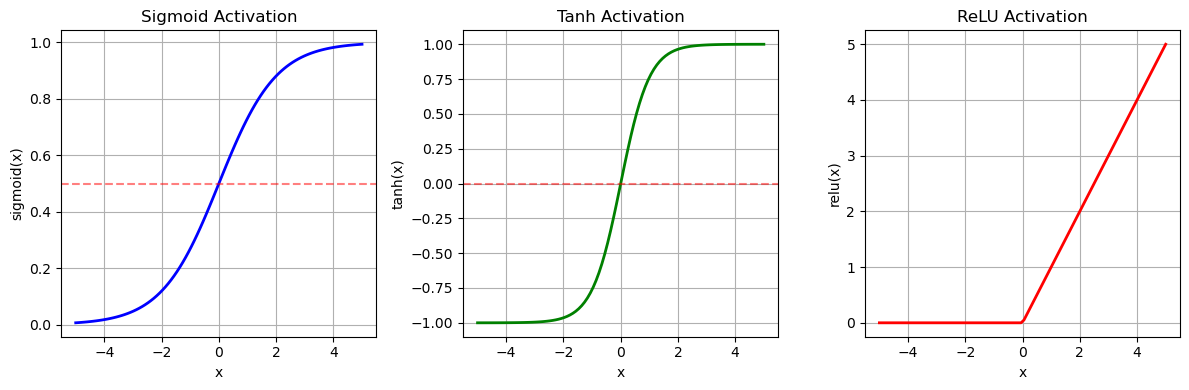

Probabilities: [0.1  0.5  0.9  0.01 0.99]
Log probabilities: [-2.30258509 -0.69314718 -0.10536052 -4.60517019 -0.01005034]
Log10: [-1.         -0.30103    -0.04575749 -2.         -0.00436481]

Clipped probabilities: [0.1  0.5  0.9  0.01 0.99]
Log of clipped: [-2.30258509 -0.69314718 -0.10536052 -4.60517019 -0.01005034]


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Common activation functions using NumPy operations
x = np.linspace(-5, 5, 100)

# Sigmoid: 1 / (1 + exp(-x))
sigmoid = 1 / (1 + np.exp(-x))

# Tanh: (exp(x) - exp(-x)) / (exp(x) + exp(-x))
tanh = np.tanh(x)

# ReLU: max(0, x)
relu = np.maximum(0, x)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x, sigmoid, 'b-', linewidth=2)
plt.title('Sigmoid Activation')
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.grid(True)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)

plt.subplot(1, 3, 2)
plt.plot(x, tanh, 'g-', linewidth=2)
plt.title('Tanh Activation')
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.grid(True)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)

plt.subplot(1, 3, 3)
plt.plot(x, relu, 'r-', linewidth=2)
plt.title('ReLU Activation')
plt.xlabel('x')
plt.ylabel('relu(x)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Logarithmic operations (used in cross-entropy loss)
probs = np.array([0.1, 0.5, 0.9, 0.01, 0.99])
print("Probabilities:", probs)
print("Log probabilities:", np.log(probs))
print("Log10:", np.log10(probs))

# Clip to avoid log(0)
epsilon = 1e-10
safe_probs = np.clip(probs, epsilon, 1 - epsilon)
print("\nClipped probabilities:", safe_probs)
print("Log of clipped:", np.log(safe_probs))

## Comparison and Logical Operations {#logical-operations}

Comparison operations are used for filtering, masking, and conditional operations in data preprocessing and model evaluation.

In [8]:
import numpy as np

# Comparison operations
a = np.array([1, 2, 3, 4, 5])
b = np.array([5, 4, 3, 2, 1])

print(f"a = {a}")
print(f"b = {b}")
print()

print("a > b:  ", a > b)
print("a >= b: ", a >= b)
print("a < b:  ", a < b)
print("a <= b: ", a <= b)
print("a == b: ", a == b)
print("a != b: ", a != b)

# Boolean indexing (filtering)
data = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
mask = data > 5
print(f"\nData: {data}")
print(f"Mask (data > 5): {mask}")
print(f"Filtered data: {data[mask]}")

# Logical operations
x = np.array([True, False, True, False])
y = np.array([True, True, False, False])

print(f"\nx = {x}")
print(f"y = {y}")
print(f"np.logical_and(x, y): {np.logical_and(x, y)}")
print(f"np.logical_or(x, y):  {np.logical_or(x, y)}")
print(f"np.logical_not(x):    {np.logical_not(x)}")

# Counting and checking
print(f"\nnp.any(a > 3): {np.any(a > 3)}")    # Any element > 3?
print(f"np.all(a > 0): {np.all(a > 0)}")    # All elements > 0?
print(f"np.sum(a > 3): {np.sum(a > 3)}")    # Count of elements > 3

a = [1 2 3 4 5]
b = [5 4 3 2 1]

a > b:   [False False False  True  True]
a >= b:  [False False  True  True  True]
a < b:   [ True  True False False False]
a <= b:  [ True  True  True False False]
a == b:  [False False  True False False]
a != b:  [ True  True False  True  True]

Data: [ 1  2  3  4  5  6  7  8  9 10]
Mask (data > 5): [False False False False False  True  True  True  True  True]
Filtered data: [ 6  7  8  9 10]

x = [ True False  True False]
y = [ True  True False False]
np.logical_and(x, y): [ True False False False]
np.logical_or(x, y):  [ True  True  True False]
np.logical_not(x):    [False  True False  True]

np.any(a > 3): True
np.all(a > 0): True
np.sum(a > 3): 2


## Practical AI/ML Examples {#ml-examples}

Let's apply what we've learned to real ML scenarios. These examples demonstrate why broadcasting and vectorization are so powerful.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Example 1: Vectorized Mean Squared Error
def mse_vectorized(y_true, y_pred):
    """Compute MSE without loops"""
    return np.mean((y_true - y_pred) ** 2)

y_true = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_pred = np.array([1.1, 1.9, 3.2, 3.8, 5.1])

loss = mse_vectorized(y_true, y_pred)
print(f"MSE: {loss:.4f}")

# Example 2: Batch Normalization Simulation
print("\n--- Batch Normalization Simulation ---")
batch_data = np.random.randn(4, 3)  # 4 samples, 3 features
print(f"Original batch shape: {batch_data.shape}")

# Compute statistics along batch dimension (axis=0)
batch_mean = np.mean(batch_data, axis=0, keepdims=True)
batch_var = np.var(batch_data, axis=0, keepdims=True)

print(f"Batch mean shape: {batch_mean.shape}")
print(f"Batch var shape: {batch_var.shape}")

# Normalize (broadcasting in action!)
epsilon = 1e-8
normalized = (batch_data - batch_mean) / np.sqrt(batch_var + epsilon)
print(f"\nNormalized data shape: {normalized.shape}")
print(f"New mean (should be ~0): {np.mean(normalized, axis=0)}")
print(f"New std (should be ~1): {np.std(normalized, axis=0)}")

MSE: 0.0220

--- Batch Normalization Simulation ---
Original batch shape: (4, 3)
Batch mean shape: (1, 3)
Batch var shape: (1, 3)

Normalized data shape: (4, 3)
New mean (should be ~0): [5.55111512e-17 0.00000000e+00 0.00000000e+00]
New std (should be ~1): [1.         0.99999999 1.        ]


Points:
[[0 0]
 [3 4]
 [6 8]
 [1 1]]

Pairwise distance matrix:
[[ 0.          5.         10.          1.41421356]
 [ 5.          0.          5.          3.60555128]
 [10.          5.          0.          8.60232527]
 [ 1.41421356  3.60555128  8.60232527  0.        ]]


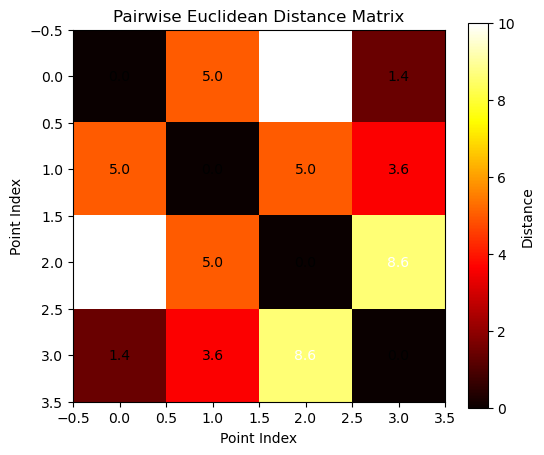

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Example 3: Euclidean Distance Matrix with Broadcasting
def pairwise_distances_broadcast(X):
    """Compute pairwise Euclidean distances using broadcasting"""
    # X shape: (n_samples, n_features)
    # Result: (n_samples, n_samples) distance matrix
    sum_sq = np.sum(X**2, axis=1, keepdims=True)  # Shape: (n, 1)
    # Broadcasting: (n, 1) + (1, n) - 2*(n, n)
    distances = np.sqrt(sum_sq + sum_sq.T - 2 * np.dot(X, X.T))
    return distances

# Create sample data points
points = np.array([[0, 0],
                   [3, 4],
                   [6, 8],
                   [1, 1]])

dist_matrix = pairwise_distances_broadcast(points)
print("Points:")
print(points)
print("\nPairwise distance matrix:")
print(dist_matrix)

# Visualize distance matrix
plt.figure(figsize=(6, 5))
plt.imshow(dist_matrix, cmap='hot', interpolation='nearest')
plt.colorbar(label='Distance')
plt.title('Pairwise Euclidean Distance Matrix')
plt.xlabel('Point Index')
plt.ylabel('Point Index')
for i in range(len(points)):
    for j in range(len(points)):
        plt.text(j, i, f'{dist_matrix[i, j]:.1f}', 
                ha='center', va='center', color='white' if dist_matrix[i, j] > 5 else 'black')
plt.show()

--- Performance: Loop vs Vectorized ---
Size 100x100: Loop=0.0184s, Vectorized=0.0027s, Speedup=6.8x
Size 500x500: Loop=0.5053s, Vectorized=0.0017s, Speedup=291.4x
Size 1000x1000: Loop=2.4452s, Vectorized=0.0064s, Speedup=384.4x
Size 2000x2000: Loop=9.9732s, Vectorized=0.0309s, Speedup=322.4x


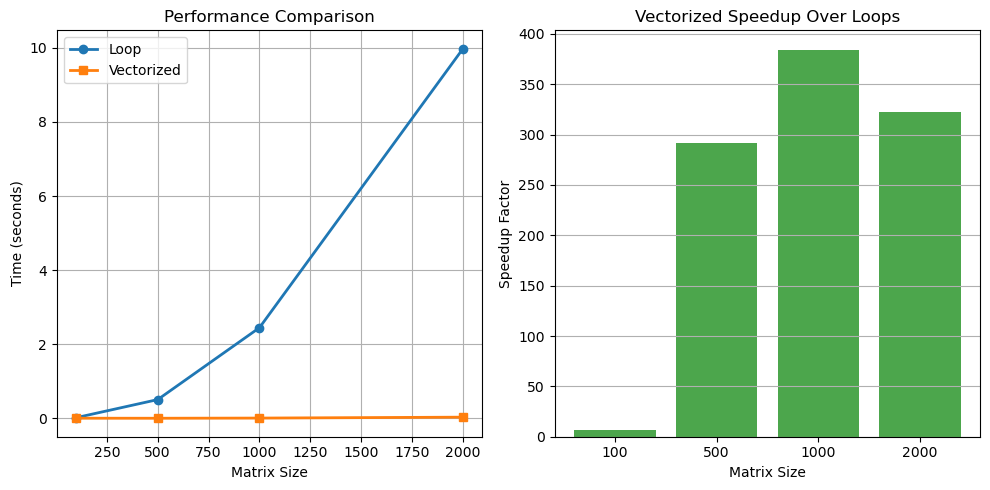

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Example 4: Performance comparison - Loop vs Vectorized
print("--- Performance: Loop vs Vectorized ---")

sizes = [100, 500, 1000, 2000]
loop_times = []
vectorized_times = []

for size in sizes:
    a = np.random.randn(size, size)
    b = np.random.randn(size, size)
    
    # Loop version
    start = time.time()
    result_loop = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            result_loop[i, j] = a[i, j] + b[i, j]
    loop_time = time.time() - start
    loop_times.append(loop_time)
    
    # Vectorized version
    start = time.time()
    result_vec = a + b
    vec_time = time.time() - start
    vectorized_times.append(vec_time)
    
    print(f"Size {size}x{size}: Loop={loop_time:.4f}s, Vectorized={vec_time:.4f}s, Speedup={loop_time/vec_time:.1f}x")

# Plot comparison
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(sizes, loop_times, 'o-', label='Loop', linewidth=2)
plt.plot(sizes, vectorized_times, 's-', label='Vectorized', linewidth=2)
plt.xlabel('Matrix Size')
plt.ylabel('Time (seconds)')
plt.title('Performance Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
speedups = [l/v for l, v in zip(loop_times, vectorized_times)]
plt.bar([str(s) for s in sizes], speedups, color='green', alpha=0.7)
plt.xlabel('Matrix Size')
plt.ylabel('Speedup Factor')
plt.title('Vectorized Speedup Over Loops')
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

--- Vectorized Linear Regression ---
True parameters: w=2.0, b=1.0
Predicted parameters: w=1.928, b=1.004
MSE: 0.2209


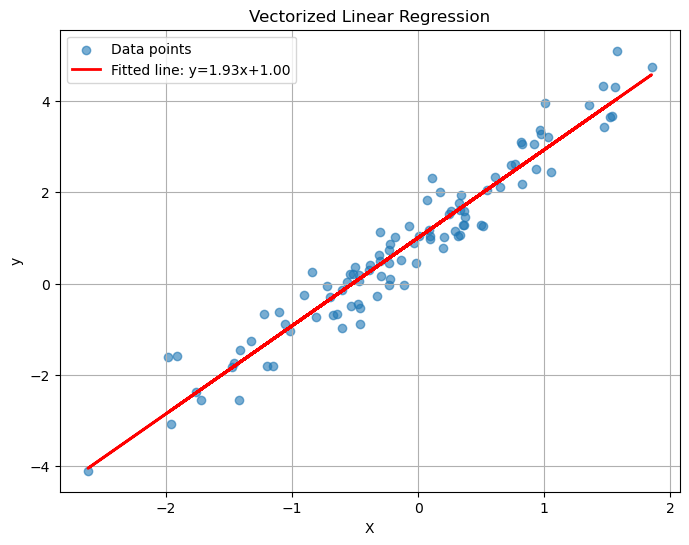

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Example 5: Simple Vectorized Linear Regression
print("--- Vectorized Linear Regression ---")

# Generate synthetic data: y = 2x + 1 + noise
np.random.seed(42)
n_samples = 100
X = np.random.randn(n_samples)
true_w, true_b = 2.0, 1.0
y = true_w * X + true_b + np.random.randn(n_samples) * 0.5

# Add bias term (column of ones) using broadcasting
X_b = np.c_[X, np.ones(n_samples)]  # Shape: (n_samples, 2)

# Normal equation: theta = (X^T X)^(-1) X^T y
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
w_pred, b_pred = theta

print(f"True parameters: w={true_w}, b={true_b}")
print(f"Predicted parameters: w={w_pred:.3f}, b={b_pred:.3f}")

# Predictions
y_pred = X_b @ theta  # Matrix multiplication for all predictions

# Calculate MSE
mse = np.mean((y - y_pred) ** 2)
print(f"MSE: {mse:.4f}")

# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.6, label='Data points')
plt.plot(X, y_pred, 'r-', linewidth=2, label=f'Fitted line: y={w_pred:.2f}x+{b_pred:.2f}')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Vectorized Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

## 🛠️ Hands-On Exercises {#exercises}

Complete these exercises to master NumPy mathematical operations and broadcasting. Try to solve them without using explicit Python loops!

### Exercise 1: Basic Broadcasting
Create a 3x3 matrix of values 1-9 and multiply each row by [1, 2, 3] using broadcasting.

In [13]:
# your code here


### Exercise 2: Vectorized MSE
Implement a function that computes Mean Squared Error between two arrays without using loops.

In [14]:
# your code here


### Exercise 3: Pairwise Distances
Given a matrix X of shape (n, d), compute the pairwise squared Euclidean distances using broadcasting.

In [15]:
# your code here


### Exercise 4: Axis-wise Operations
Create a 4x5 matrix and compute the mean of each column, then subtract these means from each column to center the data.

In [16]:
# your code here


### Exercise 5: Batch Normalization
Simulate batch normalization on a batch of 5 samples with 4 features each. Compute mean and variance along the batch dimension and normalize.

In [17]:
# your code here


### Exercise 6: Sigmoid Activation
Implement the sigmoid function using NumPy and apply it to an array of values. Then compute its derivative (sigmoid * (1 - sigmoid)).

In [18]:
# your code here


### Exercise 7: Softmax Function
Implement the softmax function for a 2D array where each row represents a sample and each column represents a class score.

In [19]:
# your code here


### Exercise 8: Boolean Indexing
Create an array of 20 random integers between 0 and 100. Replace all values greater than 50 with their square root.

In [20]:
# your code here


### Exercise 9: Linear Regression Prediction
Given weights w (shape 3,), bias b (scalar), and data X (shape 10, 3), compute predictions using matrix operations.

In [21]:
# your code here


### Exercise 10: Trigonometric Features
Create a feature matrix where column 0 is x, column 1 is sin(x), and column 2 is cos(x) for x in [0, 2π] with 50 points.

In [22]:
# your code here


### Exercise 11: Advanced Broadcasting
Given a 3D array of shape (2, 3, 4) and a 1D array of shape (4,), add the 1D array to each 2D slice of the 3D array using broadcasting.

In [23]:
# your code here


## Solutions (check after attempting) {#solutions}

Below are the solutions. Try the exercises first before looking here!

### Solution 1: Basic Broadcasting

In [24]:
import numpy as np

# Create 3x3 matrix
matrix = np.arange(1, 10).reshape(3, 3)
multiplier = np.array([1, 2, 3])

print(f"Original matrix:\n{matrix}")
print(f"Multiplier: {multiplier}")

# Broadcasting: (3, 3) * (3,) -> (3, 3) * (1, 3) broadcasted
result = matrix * multiplier
print(f"\nResult:\n{result}")

# Expected output:
# [[ 1  4  9]
#  [ 4 10 18]
#  [ 7 14 27]]

Original matrix:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Multiplier: [1 2 3]

Result:
[[ 1  4  9]
 [ 4 10 18]
 [ 7 16 27]]


### Solution 2: Vectorized MSE

In [25]:
import numpy as np

def vectorized_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

y_true = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_pred = np.array([1.2, 1.8, 3.1, 3.9, 5.2])

mse = vectorized_mse(y_true, y_pred)
print(f"MSE: {mse:.4f}")

# Expected output: ~0.0280

MSE: 0.0280


### Solution 3: Pairwise Distances

In [26]:
import numpy as np

def pairwise_squared_distances(X):
    # X shape: (n, d)
    # Using: ||x_i - x_j||^2 = ||x_i||^2 + ||x_j||^2 - 2*x_i·x_j
    sum_sq = np.sum(X**2, axis=1, keepdims=True)  # (n, 1)
    distances = sum_sq + sum_sq.T - 2 * (X @ X.T)  # Broadcasting magic
    return distances

X = np.array([[0, 0], [3, 4], [6, 8]])
distances = pairwise_squared_distances(X)
print("Squared distance matrix:")
print(distances)

# Expected:
# [[  0  25 100]
#  [ 25   0  25]
#  [100  25   0]]

Squared distance matrix:
[[  0  25 100]
 [ 25   0  25]
 [100  25   0]]


### Solution 4: Axis-wise Operations

In [27]:
import numpy as np

np.random.seed(42)
matrix = np.random.randn(4, 5)
print(f"Original matrix:\n{matrix}")

# Compute column means
col_means = np.mean(matrix, axis=0, keepdims=True)
print(f"\nColumn means:\n{col_means}")

# Center the data
centered = matrix - col_means
print(f"\nCentered matrix:\n{centered}")
print(f"New column means (should be ~0): {np.mean(centered, axis=0)}")

Original matrix:
[[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
 [-0.23413696  1.57921282  0.76743473 -0.46947439  0.54256004]
 [-0.46341769 -0.46572975  0.24196227 -1.91328024 -1.72491783]
 [-0.56228753 -1.01283112  0.31424733 -0.90802408 -1.4123037 ]]

Column means:
[[-0.19078201 -0.00940309  0.49283322 -0.44193721 -0.70720372]]

Centered matrix:
[[ 0.68749616 -0.12886121  0.15485532  1.96496707  0.47305034]
 [-0.04335495  1.58861591  0.27460151 -0.02753717  1.24976376]
 [-0.27263569 -0.45632666 -0.25087095 -1.47134303 -1.01771412]
 [-0.37150552 -1.00342803 -0.17858589 -0.46608686 -0.70509999]]
New column means (should be ~0): [ 0.00000000e+00  0.00000000e+00 -4.16333634e-17  0.00000000e+00
  1.11022302e-16]


### Solution 5: Batch Normalization

In [28]:
import numpy as np

np.random.seed(42)
batch = np.random.randn(5, 4)
print(f"Original batch:\n{batch}")

# Compute statistics along batch dimension (axis=0)
mean = np.mean(batch, axis=0, keepdims=True)
var = np.var(batch, axis=0, keepdims=True)

print(f"\nMean: {mean}")
print(f"Variance: {var}")

# Normalize
epsilon = 1e-8
normalized = (batch - mean) / np.sqrt(var + epsilon)

print(f"\nNormalized batch:\n{normalized}")
print(f"New mean: {np.mean(normalized, axis=0)}")
print(f"New std: {np.std(normalized, axis=0)}")

Original batch:
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783 -0.56228753]
 [-1.01283112  0.31424733 -0.90802408 -1.4123037 ]]

Mean: [[-0.19555649 -0.28577483 -0.17389165 -0.02997128]]
Variance: [[0.28302397 0.74387299 1.35536545 1.08635157]]

Normalized batch:
[[ 1.30126065  0.17103052  0.70570265  1.49000105]
 [-0.07255053  0.05987133  1.50584264  0.7650579 ]
 [-0.51488328  0.96040972 -0.24869063 -0.4180812 ]
 [ 0.82240371 -1.88700497 -1.33226593 -0.51072195]
 [-1.53623055  0.69569341 -0.63058872 -1.3262558 ]]
New mean: [ 0.00000000e+00 -4.44089210e-17 -2.22044605e-17  8.88178420e-17]
New std: [0.99999998 0.99999999 1.         1.        ]


### Solution 6: Sigmoid Activation

In [29]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

x = np.array([-2, -1, 0, 1, 2])
print(f"Input: {x}")
print(f"Sigmoid: {sigmoid(x)}")
print(f"Derivative: {sigmoid_derivative(x)}")

# Expected sigmoid: [0.119, 0.269, 0.5, 0.731, 0.881]

Input: [-2 -1  0  1  2]
Sigmoid: [0.11920292 0.26894142 0.5        0.73105858 0.88079708]
Derivative: [0.10499359 0.19661193 0.25       0.19661193 0.10499359]


### Solution 7: Softmax Function

In [30]:
import numpy as np

def softmax(X):
    # X shape: (n_samples, n_classes)
    # Subtract max for numerical stability
    exp_X = np.exp(X - np.max(X, axis=1, keepdims=True))
    return exp_X / np.sum(exp_X, axis=1, keepdims=True)

scores = np.array([[1, 2, 3],
                   [1, 2, 1]])
probs = softmax(scores)
print("Softmax probabilities:")
print(probs)
print(f"Sum of each row (should be 1): {np.sum(probs, axis=1)}")

# Expected: each row sums to 1, higher scores get higher probabilities

Softmax probabilities:
[[0.09003057 0.24472847 0.66524096]
 [0.21194156 0.57611688 0.21194156]]
Sum of each row (should be 1): [1. 1.]


### Solution 8: Boolean Indexing

In [31]:
import numpy as np

np.random.seed(42)
arr = np.random.randint(0, 100, 20)
print(f"Original: {arr}")

# Boolean mask
mask = arr > 50
arr[mask] = np.sqrt(arr[mask])

print(f"Modified: {arr}")

# Alternative one-liner
arr2 = np.random.randint(0, 100, 20)
arr2 = np.where(arr2 > 50, np.sqrt(arr2), arr2)
print(f"\nUsing np.where: {arr2}")

Original: [51 92 14 71 60 20 82 86 74 74 87 99 23  2 21 52  1 87 29 37]
Modified: [ 7  9 14  8  7 20  9  9  8  8  9  9 23  2 21  7  1  9 29 37]

Using np.where: [ 1.          7.93725393  7.68114575 20.         32.          8.66025404
  7.54983444 21.          9.38083152 48.          9.48683298  7.61577311
 41.          9.53939201  7.68114575  8.88819442 14.          7.81024968
  7.81024968 46.        ]


### Solution 9: Linear Regression Prediction

In [32]:
import numpy as np

np.random.seed(42)
w = np.array([0.5, -0.3, 0.8])  # Shape: (3,)
b = 2.0
X = np.random.randn(10, 3)       # Shape: (10, 3)

# Method 1: Using dot product and broadcasting
predictions = X @ w + b
print(f"Predictions shape: {predictions.shape}")
print(f"Predictions: {predictions}")

# Method 2: Using bias column
X_with_bias = np.c_[X, np.ones(10)]
w_with_bias = np.append(w, b)
predictions2 = X_with_bias @ w_with_bias
print(f"\nSame predictions: {np.allclose(predictions, predictions2)}")

Predictions shape: (10,)
Predictions: [2.8079872  2.64445138 2.18379648 2.03772153 1.31503094 2.27410344
 3.14219809 0.72705484 0.773737   2.13468562]

Same predictions: True


### Solution 10: Trigonometric Features

Features shape: (50, 3)
First 5 rows:
[[0.         0.         1.        ]
 [0.12822827 0.12787716 0.99179001]
 [0.25645654 0.25365458 0.96729486]
 [0.38468481 0.375267   0.92691676]
 [0.51291309 0.49071755 0.8713187 ]]


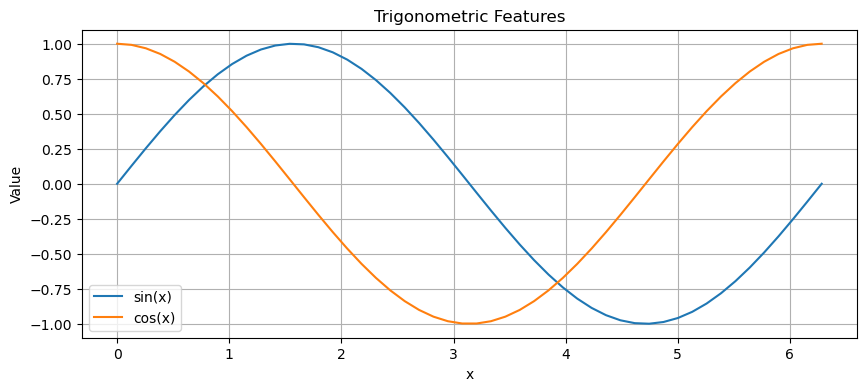

In [33]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2*np.pi, 50)
features = np.column_stack([x, np.sin(x), np.cos(x)])

print(f"Features shape: {features.shape}")
print(f"First 5 rows:\n{features[:5]}")

# Visualize
plt.figure(figsize=(10, 4))
plt.plot(x, features[:, 1], label='sin(x)')
plt.plot(x, features[:, 2], label='cos(x)')
plt.xlabel('x')
plt.ylabel('Value')
plt.title('Trigonometric Features')
plt.legend()
plt.grid(True)
plt.show()

### Solution 11: Advanced Broadcasting

In [34]:
import numpy as np

arr_3d = np.arange(24).reshape(2, 3, 4)
arr_1d = np.array([10, 20, 30, 40])

print(f"3D array shape: {arr_3d.shape}")
print(f"1D array shape: {arr_1d.shape}")

# Broadcasting: (2, 3, 4) + (4,) -> (2, 3, 4) + (1, 1, 4) -> (2, 3, 4)
result = arr_3d + arr_1d
print(f"\nResult shape: {result.shape}")
print(f"First slice:\n{result[0]}")
print(f"Second slice:\n{result[1]}")

# Verify broadcasting rules
print(f"\nOriginal first slice [0,0,:]: {arr_3d[0,0,:]}")
print(f"Added [10,20,30,40]: {result[0,0,:]}")

3D array shape: (2, 3, 4)
1D array shape: (4,)

Result shape: (2, 3, 4)
First slice:
[[10 21 32 43]
 [14 25 36 47]
 [18 29 40 51]]
Second slice:
[[22 33 44 55]
 [26 37 48 59]
 [30 41 52 63]]

Original first slice [0,0,:]: [0 1 2 3]
Added [10,20,30,40]: [10 21 32 43]


---

## 🚀 Coming Up Next: Day 12

Tomorrow we dive into **Pandas Series & DataFrames**—your first real data tool! You'll learn how to load, explore, clean, and manipulate real-world datasets. We'll cover:
- Creating and indexing Series and DataFrames
- Loading data from CSV, Excel, and databases
- Data selection, filtering, and aggregation
- Handling missing data and duplicates
- Merging and joining datasets

Get ready to work with actual data! 📊

---

**💡 Key Takeaway**: Always think in terms of vectorized operations and broadcasting when writing ML code. If you find yourself writing loops over NumPy arrays, pause and ask: "Can I do this with broadcasting?" Your code will be faster, cleaner, and more maintainable. The ability to manipulate arrays of different shapes without explicit loops is what makes NumPy (and Python ML) so powerful!

---

*Python & AI Learning Path | Day 11 / 369*